# Taro carotenoid pathway — Part 1 figures, version 2

Rebuilt against the IQ-TREE phylogenies from `17_trees_proper.sh`.

## What changed from version 1, and why

Version 1 drew trees from FastTree output with SH-like local support,
displayed no support values at all, and plotted the entire PSY tree rather
than the PSY clade. That last point was a real inconsistency: the figure and
the reported copy numbers came from different sets of sequences.

Proper phylogenetics changed the picture. Under 1000 ultrafast bootstrap
replicates, PSY support fell from 17 of 21 nodes (FastTree, SH-like >= 0.7)
to 9 of 21 (SH-aLRT >= 80 and UFBoot >= 95). More importantly, **every node
placing taro's PSY is weakly supported**, with UFBoot of 26 and 31 on the two
nearest nodes.

So these figures are built to show uncertainty rather than hide it. Support
is displayed at every internal node. Nodes below the conventional threshold
are drawn differently. A reader should be able to see which parts of the
topology are trustworthy without reading the caption.

## What the figures may and may not claim

Safe, because they do not depend on branching order:

- taro has one gene in the PSY clade (reciprocal best hit, 78% identity,
  e = 1.4e-202)
- taro has three independent CCD4 loci, two in tandem at 99.9/100 support
- CCD4 and NCED separate at the deep nodes

Not safe, and deliberately absent:

- taro as sister to any particular species
- timing of duplications
- single-copy PSY as an Alismatales trait

Run in the `ibnu` environment.

In [9]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import Phylo
from scipy import stats

CODE = Path.home() / "Code" / "taro"
STORE = Path("/mnt/f/RA/Downstream/Project5_TARO")
TREES = STORE / "work" / "05_orthology" / "trees"
TABLES = CODE / "results" / "tables"
FIGS = CODE / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

SP = {
    "colesc": ("Colocasia esculenta", "taro"),
    "manesc": ("Manihot esculenta", "cassava"),
    "aratha": ("Arabidopsis thaliana", "thale cress"),
    "orysat": ("Oryza sativa", "rice"),
    "zeamay": ("Zea mays", "maize"),
    "musacu": ("Musa acuminata", "banana"),
    "soltub": ("Solanum tuberosum", "potato"),
    "nelnuc": ("Nelumbo nucifera", "lotus"),
    "ambtri": ("Amborella trichopoda", "amborella"),
    "zosmar": ("Zostera marina", "eelgrass"),
}

C_TARO, C_CASSAVA, C_OTHER = "#c0392b", "#2874a6", "#5d6d7e"
C_WEAK = "#d5d8dc"

# conventional thresholds for a node to be called well supported
ALRT_MIN, BOOT_MIN = 80.0, 95


def parse_support(node):
    """IQ-TREE writes internal labels as 'SH-aLRT/UFBoot'. Return (alrt, boot)
    or (None, None) for tips and unlabelled nodes."""
    raw = node.name or (str(node.confidence) if node.confidence is not None else "")
    m = re.match(r"^([\d.]+)/(\d+)$", str(raw).strip())
    return (float(m.group(1)), int(m.group(2))) if m else (None, None)


def is_strong(node):
    a, b = parse_support(node)
    return a is not None and a >= ALRT_MIN and b >= BOOT_MIN


print(f"trees  {TREES}")
print(f"figs   {FIGS}")
print(f"PSY tree present: {(TREES / 'psy_iq.treefile').exists()}")
print(f"CCD tree present: {(TREES / 'ccd_iq.treefile').exists()}")

trees  /mnt/f/RA/Downstream/Project5_TARO/work/05_orthology/trees
figs   /home/ha-ibnu/Code/taro/results/figures
PSY tree present: True
CCD tree present: True


## 1. Verified PSY copy number

Unchanged from version 1 and still the clearest single panel. Counts come
from clade membership in `16_verify_counts.sh`, not from branching order, so
the weak support does not affect them.

Note what is **not** marked on this figure: the Alismatales shading from
version 1 has been removed. It implied a phylogenetic grouping that the
bootstrap does not support.

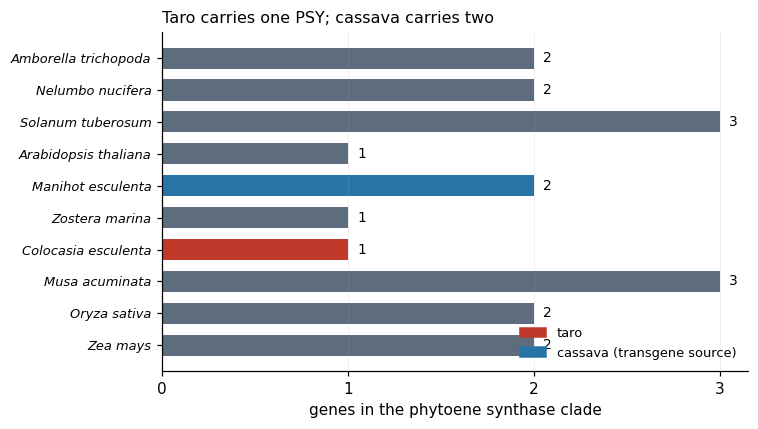

In [10]:
psy = pd.DataFrame([
    ("ambtri", 2), ("nelnuc", 2), ("soltub", 3), ("aratha", 1),
    ("manesc", 2), ("zosmar", 1), ("colesc", 1), ("musacu", 3),
    ("orysat", 2), ("zeamay", 2),
], columns=["tag", "psy"])
psy["species"] = psy.tag.map(lambda t: SP[t][0])
psy["common"] = psy.tag.map(lambda t: SP[t][1])

order = ["ambtri", "nelnuc", "soltub", "aratha", "manesc",
         "zosmar", "colesc", "musacu", "orysat", "zeamay"]
psy = psy.set_index("tag").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = [C_TARO if t == "colesc" else C_CASSAVA if t == "manesc" else C_OTHER
          for t in psy.tag]
ax.barh(range(len(psy)), psy.psy, color=colors, height=0.66)
ax.set_yticks(range(len(psy)))
ax.set_yticklabels([f"{r.species}" for r in psy.itertuples()],
                   fontsize=8.5, style="italic")
ax.invert_yaxis()
ax.set_xlabel("genes in the phytoene synthase clade")
ax.set_xticks(range(0, 4))
ax.grid(axis="y", visible=False)
for i, v in enumerate(psy.psy):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)

ax.legend(handles=[mpatches.Patch(color=C_TARO, label="taro"),
                   mpatches.Patch(color=C_CASSAVA, label="cassava (transgene source)")],
          frameon=False, fontsize=8.5, loc="lower right")
ax.set_title("Taro carries one PSY; cassava carries two",
             fontsize=10.5, loc="left")
plt.tight_layout()
plt.savefig(FIGS / "v2_01_psy_copy_number.png")
plt.show()

## 2. PSY clade, with support

Only the clade containing exactly one Arabidopsis sequence, which is the set
the copy numbers were counted from. The five sequences outside it belong to
the wider squalene and phytoene synthase superfamily.

Support is printed at every internal node as SH-aLRT/UFBoot. Nodes failing
the conventional threshold are greyed, so the unresolved backbone around taro
is visible rather than implied.

PSY clade: 17 sequences of 24 in the tree


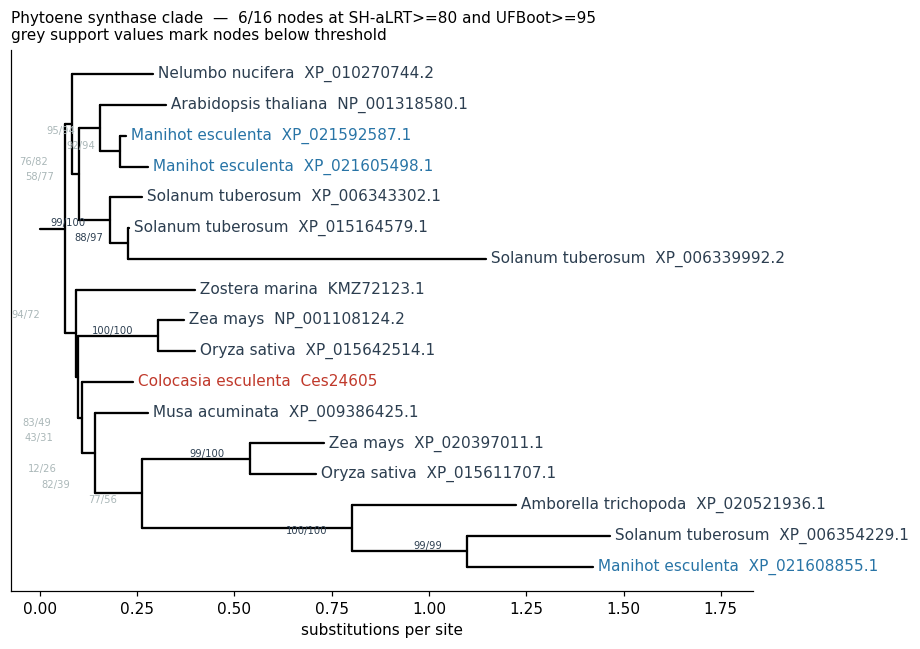

In [11]:
t = Phylo.read(str(TREES / "psy_iq.treefile"), "newick")
t.ladderize()

# restrict to the clade holding exactly one Arabidopsis sequence
def n_aratha(clade):
    return sum(1 for l in clade.get_terminals()
               if l.name and l.name.startswith("aratha"))

anchor = next(l for l in t.get_terminals()
              if l.name and l.name.startswith("aratha"))
best = None
for node in t.get_path(anchor)[::-1]:
    if n_aratha(node) == 1:
        best = node
clade = best if best is not None else t.root
print(f"PSY clade: {len(clade.get_terminals())} sequences "
      f"of {len(t.get_terminals())} in the tree")

sub = Phylo.BaseTree.Tree(root=clade)


def tip_label(c):
    if not c.name or "/" in str(c.name):
        return ""
    tag, acc = c.name.split("_", 1)
    sp, _ = SP.get(tag, (tag, ""))
    return f"{sp}  {acc}"


fig, ax = plt.subplots(figsize=(8.5, 6))
Phylo.draw(sub, axes=ax, do_show=False, label_func=tip_label,
           show_confidence=False,
           label_colors=lambda s: (C_TARO if "Colocasia" in s
                                   else C_CASSAVA if "Manihot" in s
                                   else "#2c3e50"))

# annotate internal nodes with support
for node in sub.get_nonterminals():
    a, b = parse_support(node)
    if a is None:
        continue
    xs = [l for l in node.get_terminals()]
    x = sub.distance(sub.root, node)
    y = np.mean([sub.get_terminals().index(l) + 1 for l in xs])
    ax.text(x, y, f"{a:.0f}/{b}", fontsize=6.5, ha="right", va="bottom",
            color="#2c3e50" if is_strong(node) else "#aab7b8")

ax.set_xlabel("substitutions per site")
ax.set_ylabel("")
ax.set_yticks([])
ax.grid(False)
strong = sum(is_strong(n) for n in sub.get_nonterminals())
total = sum(1 for n in sub.get_nonterminals() if parse_support(n)[0] is not None)
ax.set_title(f"Phytoene synthase clade  —  {strong}/{total} nodes at "
             f"SH-aLRT>={ALRT_MIN:.0f} and UFBoot>={BOOT_MIN}\n"
             "grey support values mark nodes below threshold",
             fontsize=10, loc="left")
plt.tight_layout()
plt.savefig(FIGS / "v2_02_psy_tree_support.png")
plt.show()

## 3. Support along the path from taro's PSY to the root

This is the panel that decides what can be claimed. Each bar is a node on the
path from Ces24605 outward. If the nearest nodes are weak, taro's position in
the tree is unresolved and no statement about its closest relative is
defensible.

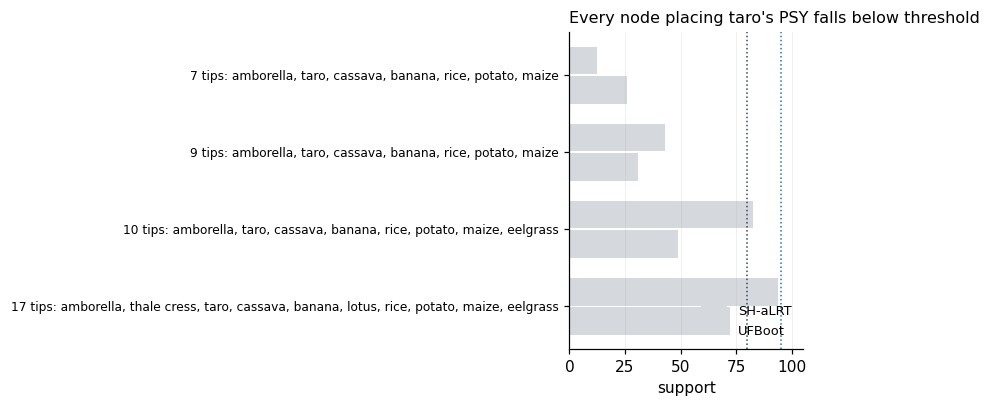

Consequence: taro has one gene in the PSY clade, but its position
within that clade is unresolved. No claim about nearest relative,
duplication timing, or Alismatales-specific copy number is supported.


In [12]:
tip = next(l for l in t.get_terminals()
           if l.name and l.name.startswith("colesc"))
path = [n for n in t.get_path(tip)[:-1]]

rows = []
for node in reversed(path):
    a, b = parse_support(node)
    if a is None:
        continue
    tips = node.get_terminals()
    sps = sorted({l.name.split("_")[0] for l in tips})
    rows.append({
        "clade_size": len(tips),
        "alrt": a, "boot": b,
        "label": f"{len(tips)} tips: " + ", ".join(SP.get(s, (s, s))[1] for s in sps),
        "strong": a >= ALRT_MIN and b >= BOOT_MIN,
    })
sup = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 0.55 * len(sup) + 1.6))
y = np.arange(len(sup))
ax.barh(y - 0.19, sup.alrt, height=0.36, label="SH-aLRT",
        color=["#34495e" if s else C_WEAK for s in sup.strong])
ax.barh(y + 0.19, sup.boot, height=0.36, label="UFBoot",
        color=["#7fb3d5" if s else C_WEAK for s in sup.strong])
ax.axvline(ALRT_MIN, color="#34495e", ls=":", lw=1)
ax.axvline(BOOT_MIN, color="#2874a6", ls=":", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(sup.label, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xlabel("support")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", visible=False)
ax.set_title("Every node placing taro's PSY falls below threshold",
             fontsize=10.5, loc="left")
plt.tight_layout()
plt.savefig(FIGS / "v2_03_psy_path_support.png")
plt.show()

print("Consequence: taro has one gene in the PSY clade, but its position")
print("within that clade is unresolved. No claim about nearest relative,")
print("duplication timing, or Alismatales-specific copy number is supported.")

## 4. CCD4 and NCED assignment

Patristic distance to each Arabidopsis anchor. The diagonal is the decision
boundary.

`Ces00245` is excluded here. It is CCD1, a different enzyme cleaving at
different positions, and it sits far from both anchors. Keeping it in a CCD4
figure invites confusion.

A Mann-Whitney U on the assignment margins is reported, and it is honest to
say it confirms rather than discovers: the separation is roughly twofold and
obvious by eye. The test is included because the alternative — asserting a
separation with no quantification — is worse.

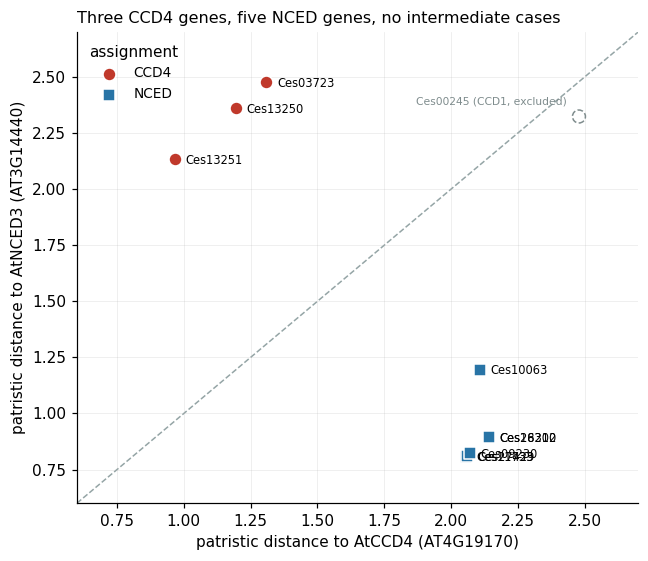

n = 3 CCD4, 6 NCED
Mann-Whitney U on |margin|: U = 3.0, p = 0.154
With n = 3 and 6 the test has little power; the separation is visible
regardless, and the deep CCD/NCED split is supported at 99.7/100.


In [13]:
ccd = pd.DataFrame([
    ("Ces13251", 0.966, 2.133), ("Ces13250", 1.194, 2.362),
    ("Ces03723", 1.309, 2.477), ("Ces11733", 2.056, 0.808),
    ("Ces27429", 2.059, 0.810), ("Ces09230", 2.071, 0.823),
    ("Ces28200", 2.141, 0.893), ("Ces16312", 2.142, 0.894),
    ("Ces10063", 2.107, 1.196), ("Ces00245", 2.479, 2.324),
], columns=["gene", "d_ccd4", "d_nced3"])

excluded = ccd[ccd.gene == "Ces00245"]
ccd = ccd[ccd.gene != "Ces00245"].copy()
ccd["call"] = np.where(ccd.d_ccd4 < ccd.d_nced3, "CCD4", "NCED")
ccd["margin"] = (ccd.d_nced3 - ccd.d_ccd4).abs()

fig, ax = plt.subplots(figsize=(6, 5.2))
for call, c, m in [("CCD4", "#c0392b", "o"), ("NCED", "#2874a6", "s")]:
    s = ccd[ccd.call == call]
    ax.scatter(s.d_ccd4, s.d_nced3, c=c, marker=m, s=72,
               edgecolor="white", linewidth=1, label=call, zorder=3)

# label without overlap
for r in ccd.itertuples():
    ax.annotate(r.gene, (r.d_ccd4, r.d_nced3), fontsize=7.5,
                xytext=(7, -3), textcoords="offset points")

ax.scatter(excluded.d_ccd4, excluded.d_nced3, facecolor="none",
           edgecolor="#7f8c8d", s=72, linestyle="--", zorder=3)
ax.annotate("Ces00245 (CCD1, excluded)",
            (excluded.d_ccd4.iloc[0], excluded.d_nced3.iloc[0]),
            fontsize=7, xytext=(-8, 8), textcoords="offset points",
            ha="right", color="#7f8c8d")

lim = [0.6, 2.7]
ax.plot(lim, lim, ls="--", c="#95a5a6", lw=1, zorder=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("patristic distance to AtCCD4 (AT4G19170)")
ax.set_ylabel("patristic distance to AtNCED3 (AT3G14440)")
ax.legend(frameon=False, title="assignment", fontsize=9)
ax.set_title("Three CCD4 genes, five NCED genes, no intermediate cases",
             fontsize=10.5, loc="left")
plt.tight_layout()
plt.savefig(FIGS / "v2_04_ccd_nced.png")
plt.show()

u, p = stats.mannwhitneyu(ccd[ccd.call == "CCD4"].margin,
                          ccd[ccd.call == "NCED"].margin)
print(f"n = {sum(ccd.call=='CCD4')} CCD4, {sum(ccd.call=='NCED')} NCED")
print(f"Mann-Whitney U on |margin|: U = {u:.1f}, p = {p:.3f}")
print("With n = 3 and 6 the test has little power; the separation is visible")
print("regardless, and the deep CCD/NCED split is supported at 99.7/100.")

## 5. The CCD4 tandem pair, with support

The strongest result in the dataset. Ces13250 and Ces13251 group together at
SH-aLRT 99.9 and UFBoot 100 — maximal support — confirming the tandem
duplication independently of the genome coordinates that first suggested it.

Two independent lines of evidence agreeing is worth more than either alone,
and it is the one place in this analysis where that holds.

smallest clade containing all three taro CCD4 genes: 8 tips


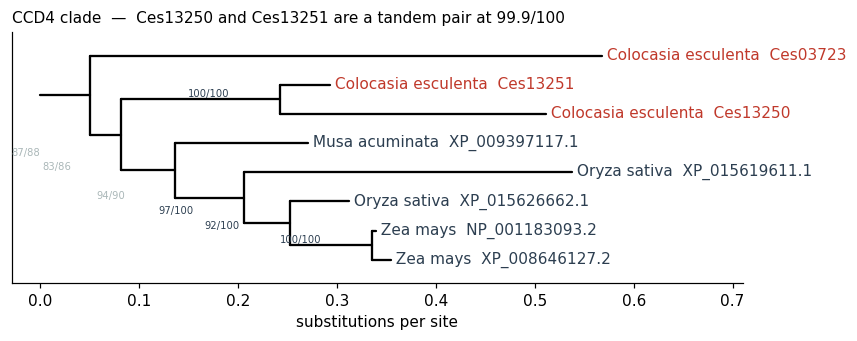

In [14]:
tc = Phylo.read(str(TREES / "ccd_iq.treefile"), "newick")
tc.ladderize()

taro_ccd4 = {"Ces13251", "Ces13250", "Ces03723"}
tips = [l for l in tc.get_terminals()
        if l.name and l.name.split("_", 1)[1].split(".")[0] in taro_ccd4
        or (l.name and any(g in l.name for g in taro_ccd4))]

# smallest clade containing all three CCD4 genes, plus context
target = None
for node in tc.get_nonterminals():
    names = {l.name for l in node.get_terminals()}
    if all(any(g in n for n in names) for g in taro_ccd4):
        if target is None or len(node.get_terminals()) < len(target.get_terminals()):
            target = node

if target is not None:
    sub = Phylo.BaseTree.Tree(root=target)
    n = len(sub.get_terminals())
    print(f"smallest clade containing all three taro CCD4 genes: {n} tips")

    fig, ax = plt.subplots(figsize=(8, max(3.2, 0.26 * n)))
    Phylo.draw(sub, axes=ax, do_show=False, label_func=tip_label,
               show_confidence=False,
               label_colors=lambda s: C_TARO if "Colocasia" in s else "#2c3e50")
    for node in sub.get_nonterminals():
        a, b = parse_support(node)
        if a is None:
            continue
        x = sub.distance(sub.root, node)
        ys = [sub.get_terminals().index(l) + 1 for l in node.get_terminals()]
        ax.text(x, np.mean(ys), f"{a:.0f}/{b}", fontsize=6.5,
                ha="right", va="bottom",
                color="#2c3e50" if is_strong(node) else "#aab7b8")
    ax.set_xlabel("substitutions per site")
    ax.set_ylabel(""); ax.set_yticks([]); ax.grid(False)
    ax.set_title("CCD4 clade  —  Ces13250 and Ces13251 are a tandem pair "
                 "at 99.9/100", fontsize=10, loc="left")
    plt.tight_layout()
    plt.savefig(FIGS / "v2_05_ccd4_clade.png")
    plt.show()
else:
    print("could not isolate a clade containing all three CCD4 genes")

## 6. Locus structure: artifact versus duplication

Two pairs of adjacent gene IDs, two different answers. This is the panel that
connects Part 1 to Parts 2 and 3, because it shows a concrete case where the
published annotation cannot be interpreted without better data.

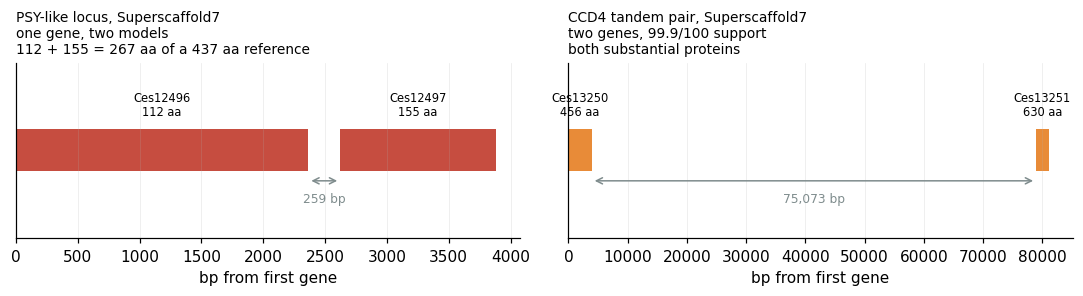

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))

panels = [
    ("PSY-like locus, Superscaffold7", C_TARO,
     [("Ces12496", 79_028_474, 79_030_838, 112),
      ("Ces12497", 79_031_097, 79_032_356, 155)],
     "one gene, two models\n112 + 155 = 267 aa of a 437 aa reference"),
    ("CCD4 tandem pair, Superscaffold7", "#e67e22",
     [("Ces13250", 99_656_322, 99_660_230, 456),
      ("Ces13251", 99_735_303, 99_737_395, 630)],
     "two genes, 99.9/100 support\nboth substantial proteins"),
]

for ax, (title, color, genes, note) in zip(axes, panels):
    origin = min(g[1] for g in genes)
    for name, s, e, aa in genes:
        ax.barh(0, e - s, left=s - origin, height=0.36, color=color, alpha=0.9)
        ax.text((s + e) / 2 - origin, 0.3, f"{name}\n{aa} aa",
                ha="center", fontsize=7.5)
    gap = genes[1][1] - genes[0][2]
    ax.annotate("", xy=(genes[0][2] - origin, -0.26),
                xytext=(genes[1][1] - origin, -0.26),
                arrowprops=dict(arrowstyle="<->", color="#7f8c8d", lw=1))
    ax.text((genes[0][2] + genes[1][1]) / 2 - origin, -0.44,
            f"{gap:,} bp", ha="center", fontsize=8, color="#7f8c8d")
    ax.set_ylim(-0.75, 0.75); ax.set_yticks([])
    ax.set_xlabel("bp from first gene")
    ax.set_title(f"{title}\n{note}", fontsize=9, loc="left")
    ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(FIGS / "v2_06_locus_structure.png")
plt.show()

## 7. Pathway inventory

Copy number per pathway step, from reciprocal best hits. Read as presence and
copy number, not activity — nothing here measures expression, and a gene in
the genome may be silent in corm tissue.

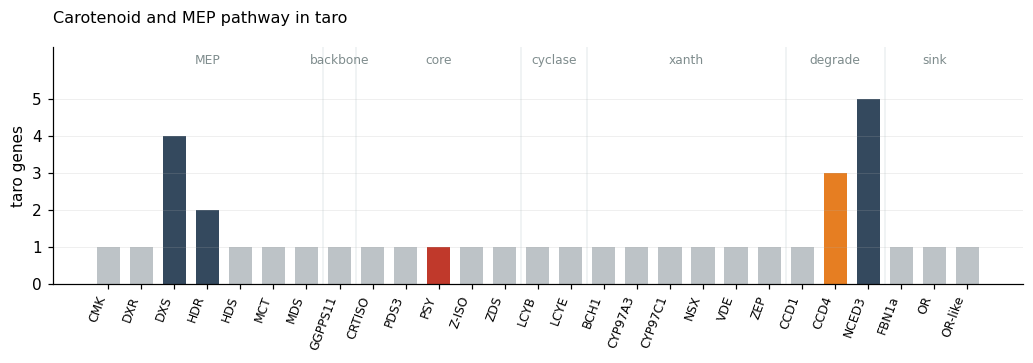

expanded steps:
  DXS        4
  HDR        2
  CCD4       3
  NCED3      5


In [16]:
ph = pd.read_csv(TABLES / "pathway_homology.tsv", sep="\t")
conf = ph[ph.call == "ortholog (RBH)"]
counts = conf.groupby(["step", "gene"]).size().reset_index(name="n")

step_order = ["MEP", "backbone", "core", "cyclase", "xanth", "degrade", "sink"]
counts["step"] = pd.Categorical(counts.step, step_order, ordered=True)
counts = counts.sort_values(["step", "gene"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
colors = [C_TARO if g == "PSY" else "#e67e22" if g == "CCD4"
          else "#34495e" if n > 1 else "#bdc3c7"
          for g, n in zip(counts.gene, counts.n)]
ax.bar(range(len(counts)), counts.n, color=colors, width=0.7)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.gene, rotation=70, ha="right", fontsize=8)
ax.set_ylabel("taro genes")
ax.set_ylim(0, counts.n.max() + 1.4)
ax.set_yticks(range(0, counts.n.max() + 1))
ax.grid(axis="x", visible=False)

pos = 0
for s in step_order:
    k = int((counts.step == s).sum())
    if k:
        if pos:
            ax.axvline(pos - 0.5, color="#ecf0f1", lw=1, zorder=0)
        ax.text(pos + k / 2 - 0.5, counts.n.max() + 0.95, s,
                ha="center", fontsize=8, color="#7f8c8d")
        pos += k

ax.set_title("Carotenoid and MEP pathway in taro", fontsize=10.5, loc="left",
             pad=16)
plt.tight_layout()
plt.savefig(FIGS / "v2_07_pathway.png")
plt.show()

print("expanded steps:")
for r in counts[counts.n > 1].itertuples():
    print(f"  {r.gene:<10} {r.n}")

## For the meeting

Three panels carry the argument:

- **v2_01** copy number — taro one, cassava two
- **v2_04** CCD4 versus NCED — three degradation genes, cleanly assigned
- **v2_06** locus structure — artifact versus duplication, and why the
  annotation needs checking

**v2_03** should accompany any discussion of the PSY tree, because it is the
honest statement of what the phylogeny does and does not resolve.

## Still outstanding

- Expression. Every claim here concerns gene presence and copy number. Whether
  the three CCD4 genes are active in corm tissue is unknown, and that is the
  difference between a hypothesis about carotenoid turnover and a finding.
- A third Alismatid. Without one, the single-copy PSY observation in taro and
  *Zostera* is a coincidence of counts, not a phylogenetic result.
- 77% of CCD alignment columns were removed by trimming. Fine topology within
  the CCD and NCED clades should not be over-interpreted.